# 05. Price prediction feature engineering

Build the price-only feature + target table used by the price prediction model (notebooks 06-08).

**Grain**: one row per `(ticker, monday_date)`, joinable to `strategy_labels.parquet`.

**Universe**: 35 HQ tickers. SPY used for market-regime features.

**Data source**: `data/daily_yf/` (production-accessible) + `data/daily_alpha/SPY.csv`. All prices use `adjusted_close` so split/dividend events don't produce spurious feature discontinuities.

**Features** (23 total, grouped for ablation):

- **momentum**: 5d/20d/60d returns and their lookback ratios
- **volatility**: 20d/60d realized vol, vol ratio, Parkinson (high-low) vol
- **trend**: close/MA(20,50,200), MA20/MA50 slope
- **drawdown**: 60d max DD, distance from 52w high
- **mean_reversion**: RSI(14), 20d z-score, Bollinger position
- **volume**: 20d volume ratio, log volume
- **spy**: SPY 20d return, 20d vol, close/MA50

**Targets**:
- `forward_ret`: `(friday_close / monday_close) - 1` (primary regression target)
- `up`: binary `forward_ret > 0`
- `cc_success_{2,3,5}pct`: binary `forward_ret < threshold` (would a CC at this OTM% expire worthless?)
- `csp_success_{2,3,5}pct`: binary `forward_ret > -threshold` (would a CSP at this OTM%?)
- `in_range_{2,3,5}pct`: `abs(forward_ret) < threshold`

**Production-inference timing**: the real workflow is to run inference in the last ~45 minutes of Monday's session (around 3:15pm ET, before options cut off at 4pm). With a free yfinance feed the quote is ~15-min delayed, so the "now" we see is ~3:00pm ET data. Training uses the true Monday-close as the input time; at inference we use the latest available quote (3:00pm ET with 15-min delay). That's a ~60-minute gap between training-time and inference-time features.

**Why this is OK for most features:** rolling statistics (MA20/50/200, vol, drawdowns, SPY features) are dominated by 50-200 days of history; an hour of intraday movement barely moves them. Features most sensitive to the exact close time are `ret_5d` (partial today), `volume_ratio_20d` (partial today's volume), `rsi_14`, and `zscore_20d`. Typical per-feature noise from this gap is <0.3% — small vs the week-to-week variation. Notebook 06 will include a robustness check: perturb the Monday features by ±0.5% and verify prediction stability.

**What's never used:** options data (orthogonality), earnings calendars, intraday microstructure (bid-ask, order book), end-of-day close price (not available at 3:00pm).

**Tickers with insufficient history**: features needing 200d or 252d lookback will be NaN for newly-listed tickers. We drop those rows here — notebook 06 can decide to impute if the model supports NaN (XGBoost does natively).

In [1]:
import time
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

from config import HIGH_QUALITY_TICKERS


LABELS_PATH = Path("output/03_weekly_strategy_labels/strategy_labels.parquet")
FEATURES_OUT = Path("output/07_price_prediction_feature_engineering/price_features.parquet")
FEATURES_CSV = Path("output/07_price_prediction_feature_engineering/price_features.csv")
OUT_DIR = Path("output/07_price_prediction_feature_engineering")
OUT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

FEATURE_GROUPS = {
    "momentum": [
        "ret_5d",
        "ret_20d",
        "ret_60d",
        "ret_5d_minus_20d",
        "ret_20d_minus_60d",
    ],
    "volatility": ["vol_20d", "vol_60d", "vol_ratio_20_60", "parkinson_vol_20d"],
    "trend": ["close_to_ma20", "close_to_ma50", "close_to_ma200", "ma20_to_ma50"],
    "drawdown": ["max_dd_60d", "dist_from_52w_high"],
    "mean_reversion": ["rsi_14", "zscore_20d", "bbands_pos"],
    "volume": ["volume_ratio_20d", "log_volume"],
    "spy": ["spy_ret_20d", "spy_vol_20d", "spy_close_to_ma50"],
}
ALL_FEATURES = [f for grp in FEATURE_GROUPS.values() for f in grp]

## Feature computation

Keep `compute_features` self-contained and importable so **production inference runs the exact same code path**. Training feeds it a stored CSV frame; production feeds it a live `yf.Ticker(...).history(period="300d", auto_adjust=True)` frame with the same columns. No train/serve skew by construction.

In [2]:
def compute_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def compute_features(ticker_df, spy_df):
    """Compute feature DataFrame indexed by date from one ticker's OHLCV + SPY's."""
    close = ticker_df["adjusted_close"]
    high = ticker_df["high"]
    low = ticker_df["low"]
    volume = ticker_df["volume"]
    log_ret = np.log(close / close.shift(1))

    feat = pd.DataFrame(index=ticker_df.index)

    # Momentum
    feat["ret_5d"] = close / close.shift(5) - 1
    feat["ret_20d"] = close / close.shift(20) - 1
    feat["ret_60d"] = close / close.shift(60) - 1
    feat["ret_5d_minus_20d"] = feat["ret_5d"] - feat["ret_20d"]
    feat["ret_20d_minus_60d"] = feat["ret_20d"] - feat["ret_60d"]

    # Volatility
    feat["vol_20d"] = log_ret.rolling(20).std() * np.sqrt(252)
    feat["vol_60d"] = log_ret.rolling(60).std() * np.sqrt(252)
    feat["vol_ratio_20_60"] = feat["vol_20d"] / feat["vol_60d"]
    hl_sq = np.log(high / low) ** 2 / (4 * np.log(2))
    feat["parkinson_vol_20d"] = np.sqrt(hl_sq.rolling(20).mean() * 252)

    # Trend
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    ma200 = close.rolling(200).mean()
    feat["close_to_ma20"] = close / ma20 - 1
    feat["close_to_ma50"] = close / ma50 - 1
    feat["close_to_ma200"] = close / ma200 - 1
    feat["ma20_to_ma50"] = ma20 / ma50 - 1

    # Drawdown
    feat["max_dd_60d"] = close / close.rolling(60).max() - 1
    feat["dist_from_52w_high"] = close / close.rolling(252).max() - 1

    # Mean reversion
    feat["rsi_14"] = compute_rsi(close, 14)
    sd20 = close.rolling(20).std()
    feat["zscore_20d"] = (close - ma20) / sd20
    feat["bbands_pos"] = (close - (ma20 - 2 * sd20)) / (4 * sd20)

    # Volume
    feat["volume_ratio_20d"] = volume / volume.rolling(20).mean()
    feat["log_volume"] = np.log(volume.replace(0, 1))

    # SPY market-regime
    spy_close = spy_df["adjusted_close"]
    spy_log_ret = np.log(spy_close / spy_close.shift(1))
    spy_feat = pd.DataFrame(index=spy_df.index)
    spy_feat["spy_ret_20d"] = spy_close / spy_close.shift(20) - 1
    spy_feat["spy_vol_20d"] = spy_log_ret.rolling(20).std() * np.sqrt(252)
    spy_feat["spy_close_to_ma50"] = spy_close / spy_close.rolling(50).mean() - 1

    return feat.join(spy_feat, how="left")

## Load daily data

`daily_yf/*.csv` for each HQ ticker + `daily_alpha/SPY.csv` as the market reference. Both use the same `adjusted_close` column.

In [3]:
daily_yf = {}
for t in HIGH_QUALITY_TICKERS:
    p = Path("data/daily_yf") / f"{t}.csv"
    if not p.exists():
        continue
    df = pd.read_csv(p, parse_dates=["date"])
    df = df.set_index("date").sort_index()
    daily_yf[t] = df
print(f"loaded {len(daily_yf)} ticker dailies")

spy_df = pd.read_csv("data/daily_alpha/SPY.csv", parse_dates=["date"])
spy_df = spy_df.set_index("date").sort_index()
print(f"SPY: {len(spy_df)} daily rows")

loaded 35 ticker dailies
SPY: 1599 daily rows


## Build per-ticker feature tables

In [4]:
t0 = time.time()
features_by_ticker = {t: compute_features(daily_yf[t], spy_df) for t in daily_yf}
print(
    f"built {len(features_by_ticker)} per-ticker feature tables in {time.time() - t0:.1f}s"
)

built 35 per-ticker feature tables in 2.0s


## Match features to (ticker, Monday) from labels

Extract each feature vector at the Monday-close of every (ticker, monday) pair in `strategy_labels.parquet`. Compute targets from the `monday_close` and `friday_close` columns we already stored in the base table.

In [5]:
labels = pd.read_parquet(LABELS_PATH)
keys = labels[
    ["ticker", "monday_date", "monday_close", "friday_date", "friday_close"]
].drop_duplicates()
keys["monday_date"] = pd.to_datetime(keys["monday_date"])
keys["friday_date"] = pd.to_datetime(keys["friday_date"])
print(f"unique (ticker, monday) pairs: {len(keys):,}")

feat_rows = []
for row in keys.itertuples():
    t = row.ticker
    mon = row.monday_date
    if t not in features_by_ticker:
        continue
    tf = features_by_ticker[t]
    try:
        fvals = tf.loc[mon] if mon in tf.index else tf.loc[:mon].iloc[-1]
    except KeyError, IndexError:
        continue
    rec = {
        "ticker": t,
        "monday_date": mon,
        "friday_date": row.friday_date,
        "monday_close": row.monday_close,
        "friday_close": row.friday_close,
    }
    for f in ALL_FEATURES:
        rec[f] = fvals.get(f, np.nan)
    feat_rows.append(rec)

features = pd.DataFrame(feat_rows)

# Targets
features["forward_ret"] = features["friday_close"] / features["monday_close"] - 1
features["up"] = (features["forward_ret"] > 0).astype(int)
for pct in [0.02, 0.03, 0.05]:
    tag = f"{int(pct * 100)}pct"
    features[f"cc_success_{tag}"] = (features["forward_ret"] < pct).astype(int)
    features[f"csp_success_{tag}"] = (features["forward_ret"] > -pct).astype(int)
    features[f"in_range_{tag}"] = (features["forward_ret"].abs() < pct).astype(int)

pre_drop = len(features)
features_clean = features.dropna(subset=ALL_FEATURES).reset_index(drop=True)
dropped = pre_drop - len(features_clean)
print(
    f"{pre_drop:,} total rows, {dropped:,} dropped for NaN features, {len(features_clean):,} clean rows"
)

features_clean.to_parquet(FEATURES_OUT, index=False)
features_clean.to_csv(FEATURES_CSV, index=False)
print(f"saved -> {FEATURES_OUT} ({FEATURES_OUT.stat().st_size / 1024:.0f} KB)")

unique (ticker, monday) pairs: 6,902
6,902 total rows, 271 dropped for NaN features, 6,631 clean rows
saved -> D:\AT82.04-Option-Screener-with-Price-Prediction\experiments\data\price_features.parquet (1435 KB)


## Preview

In [6]:
features_clean.head(3)

,ticker,monday_date,friday_date,monday_close,friday_close,ret_5d,ret_20d,ret_60d,ret_5d_minus_20d,ret_20d_minus_60d,vol_20d,vol_60d,vol_ratio_20_60,parkinson_vol_20d,close_to_ma20,close_to_ma50,close_to_ma200,ma20_to_ma50,max_dd_60d,dist_from_52w_high,rsi_14,zscore_20d,bbands_pos,volume_ratio_20d,log_volume,spy_ret_20d,spy_vol_20d,spy_close_to_ma50,forward_ret,up,cc_success_2pct,csp_success_2pct,in_range_2pct,cc_success_3pct,csp_success_3pct,in_range_3pct,cc_success_5pct,csp_success_5pct,in_range_5pct
0,AAPL,2020-02-24,2020-02-28,298.18,273.36,-0.082382,-0.061017,0.122077,-0.021365,-0.183094,0.357163,0.252231,1.416018,0.232765,-0.062935,-0.022931,0.248180,0.042691,-0.088692,-0.088692,43.074886,-2.703038,-0.175760,1.639714,19.219067,-0.019314,0.183810,-0.013287,-0.083238,0,1,0,0,1,0,0,1,0,0
1,AAPL,2020-03-02,2020-03-06,298.81,289.03,0.002113,-0.032279,0.154439,0.034392,-0.186718,0.509017,0.345817,1.471925,0.360519,-0.037639,-0.024193,0.238561,0.013971,-0.086766,-0.086766,39.409434,-0.683412,0.329147,2.031717,19.648557,-0.039288,0.297125,-0.050993,-0.032730,0,1,0,0,1,0,0,1,1,1
2,AAPL,2020-03-09,2020-03-13,266.17,277.97,-0.109233,-0.168297,-0.006251,0.059064,-0.162046,0.604949,0.406074,1.489753,0.404742,-0.121396,-0.132825,0.091571,-0.013009,-0.186522,-0.186522,32.265837,-1.888465,0.027884,1.452798,19.474103,-0.174503,0.446246,-0.152126,0.044333,1,0,1,0,0,1,0,1,1,1


## Baseline: RandomForest on forward_ret

Temporal 80/20 split (train on pre-2025-06, test on post). RandomForest with modest depth=8 as a non-overfit baseline.

**Setting expectations**: weekly forward return is extremely hard to predict from price history alone. Academic literature reports test R² typically in the range of 0.00 to 0.05 for daily/weekly horizons, with many published models having *negative* out-of-sample R² despite strong in-sample fits. If the baseline here lands near 0 (or slightly negative), that's not a bug — it's the efficient-market null hypothesis asserting itself. What matters for the strategy layer is whether the model:

1. Has *some* consistent directional edge (e.g., AUC > 0.52 for classification targets like `cc_success_3pct`)
2. Has *calibrated* probability outputs when thresholded against BS-implied `p_mkt_success`
3. Is *robust* across the feature ablation — signal comes from multiple groups, not overfitting to one quirk

Even a small edge, consistently applied, compounds. The ablation below is the real diagnostic — which feature groups contribute edge (negative ΔR² when dropped), vs which add noise (positive ΔR² when dropped).


In [7]:
features_clean["monday_date"] = pd.to_datetime(features_clean["monday_date"])
split_date = features_clean["monday_date"].quantile(0.8)
train = features_clean[features_clean["monday_date"] < split_date]
test = features_clean[features_clean["monday_date"] >= split_date]

X_train = train[ALL_FEATURES].values
y_train = train["forward_ret"].values
X_test = test[ALL_FEATURES].values
y_test = test["forward_ret"].values

print(f"split at {split_date.date()}: train={len(train):,}, test={len(test):,}")

rf = RandomForestRegressor(
    n_estimators=200, max_depth=8, min_samples_leaf=20, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = float(np.mean((y_test - y_pred_rf) ** 2))
print(f"RF test R² = {r2_rf:.4f}, MSE = {mse_rf:.6f}")

split at 2025-06-02: train=5,292, test=1,339
RF test R² = -0.0151, MSE = 0.008010


## Feature importance (RF)

Horizontal bars color-coded by feature group. Big bars dominate the model's decisions; tiny bars are candidates to drop.

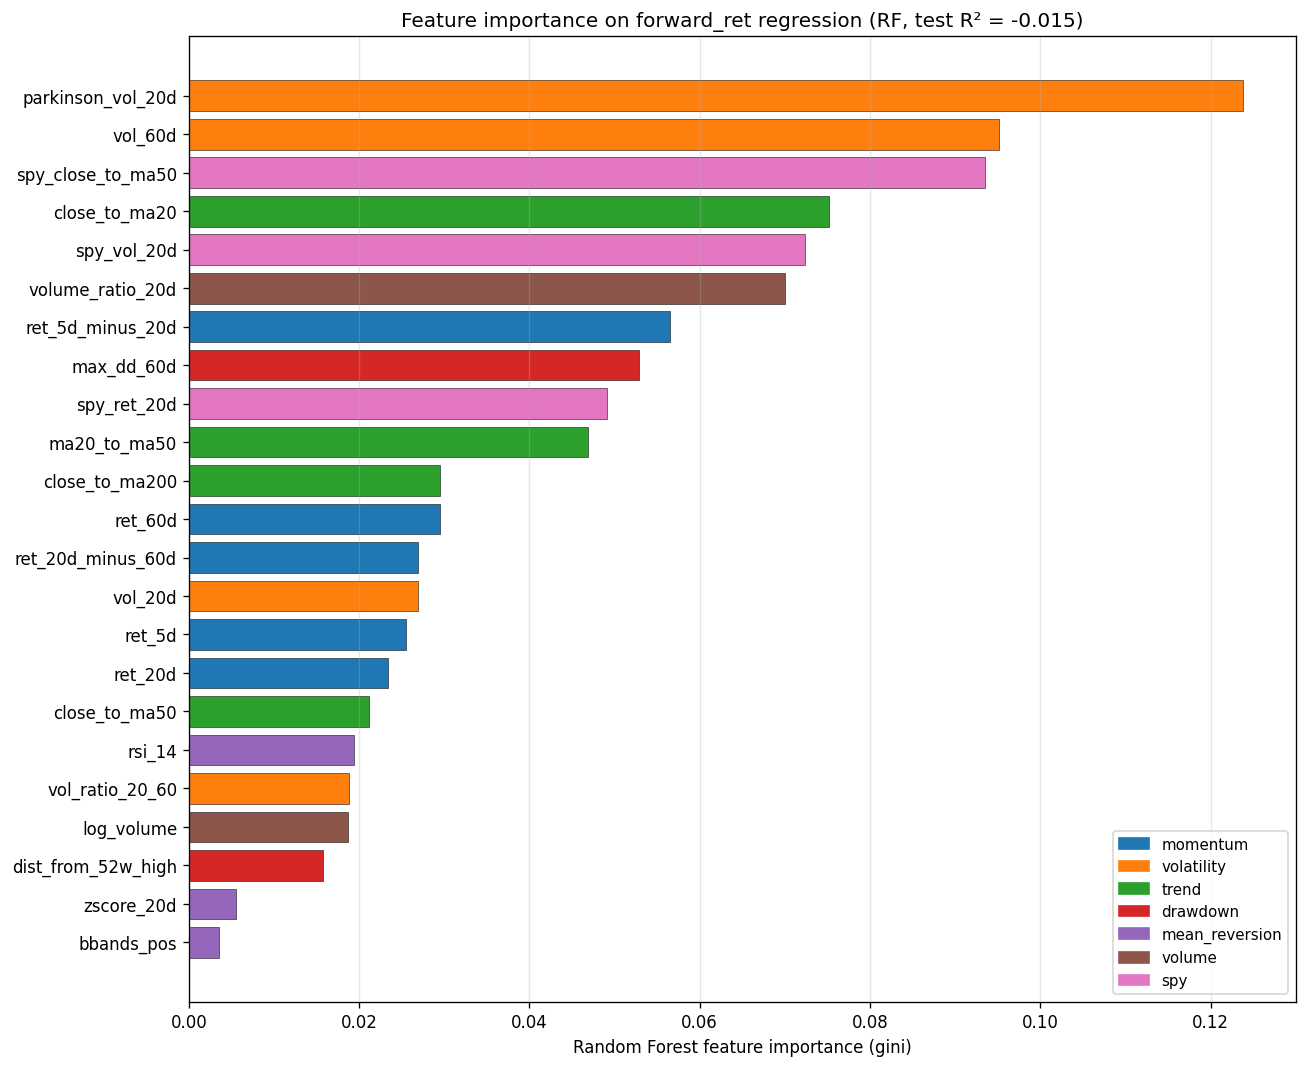

In [8]:
importance = pd.DataFrame(
    {
        "feature": ALL_FEATURES,
        "importance": rf.feature_importances_,
        "group": [
            next(g for g, feats in FEATURE_GROUPS.items() if f in feats)
            for f in ALL_FEATURES
        ],
    }
).sort_values("importance", ascending=True)

group_colors = {
    "momentum": "tab:blue",
    "volatility": "tab:orange",
    "trend": "tab:green",
    "drawdown": "tab:red",
    "mean_reversion": "tab:purple",
    "volume": "tab:brown",
    "spy": "tab:pink",
}

fig, ax = plt.subplots(figsize=(11, 9))
colors = [group_colors[g] for g in importance["group"]]
ax.barh(
    importance["feature"],
    importance["importance"],
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)
ax.set_xlabel("Random Forest feature importance (gini)")
ax.set_title(
    f"Feature importance on forward_ret regression (RF, test R² = {r2_rf:.3f})"
)
ax.grid(alpha=0.3, axis="x")
handles = [Patch(color=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=handles, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Feature-group ablation

For each feature group, drop all its members, re-fit RF, measure test R². Big negative delta = that group carries real signal. Positive delta = dropping it *helped* (regularization effect, suggests the group was adding noise).

In [9]:
ablation_rows = [
    {"ablation": "ALL (baseline)", "n_features": len(ALL_FEATURES), "test_r2": r2_rf}
]
for group, feats in FEATURE_GROUPS.items():
    dropped_features = [f for f in ALL_FEATURES if f not in feats]
    X_tr = train[dropped_features].values
    X_te = test[dropped_features].values
    rf_ab = RandomForestRegressor(
        n_estimators=200, max_depth=8, min_samples_leaf=20, n_jobs=-1, random_state=SEED
    )
    rf_ab.fit(X_tr, y_train)
    r2_ab = r2_score(y_test, rf_ab.predict(X_te))
    ablation_rows.append(
        {
            "ablation": f"drop {group}",
            "n_features": len(dropped_features),
            "test_r2": r2_ab,
        }
    )

ablation_df = pd.DataFrame(ablation_rows)
ablation_df["delta_from_baseline"] = ablation_df["test_r2"] - r2_rf
ablation_df.round(4)

,ablation,n_features,test_r2,delta_from_baseline
0,ALL (baseline),23,-0.0151,0.0000
1,drop momentum,18,-0.0242,-0.0091
2,drop volatility,19,-0.0252,-0.0101
3,drop trend,19,-0.0037,0.0114
4,drop drawdown,21,-0.0177,-0.0025
5,drop mean_reversion,20,-0.0107,0.0045
6,drop volume,21,-0.0162,-0.0011
7,drop spy,20,-0.0405,-0.0254


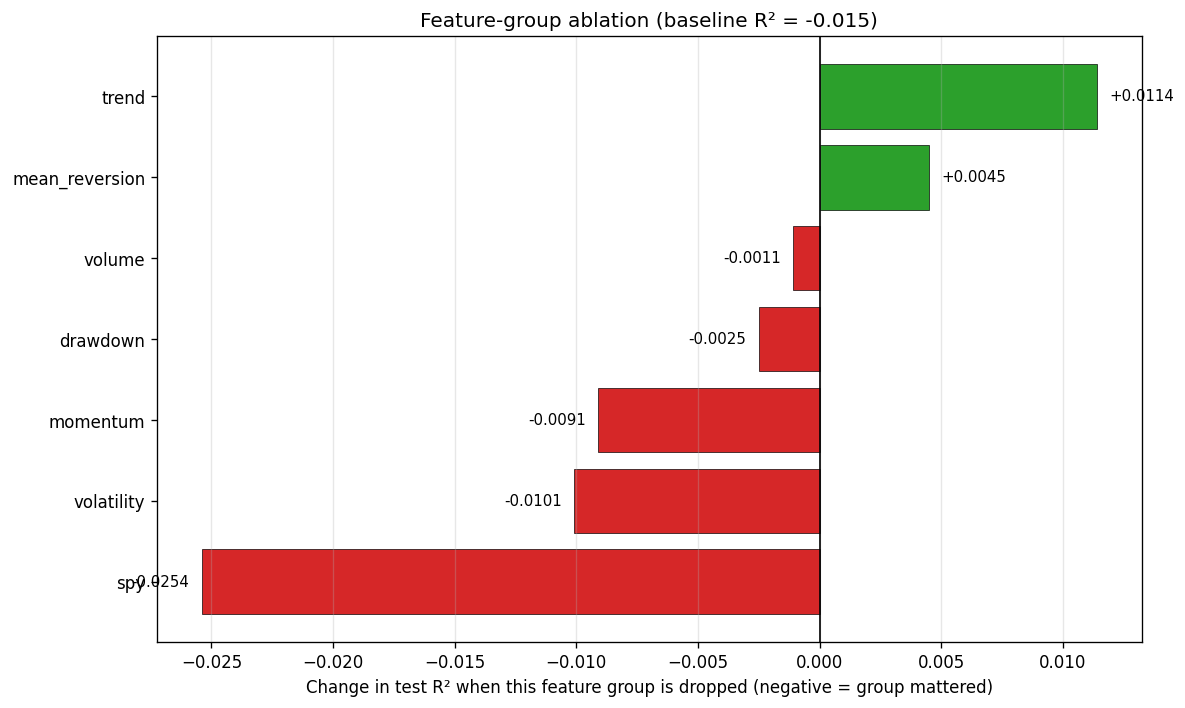

In [10]:
rows = ablation_df.iloc[1:].sort_values("delta_from_baseline")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tab:red" if d < 0 else "tab:green" for d in rows["delta_from_baseline"]]
ax.barh(
    [r.replace("drop ", "") for r in rows["ablation"]],
    rows["delta_from_baseline"],
    color=colors,
    edgecolor="black",
    linewidth=0.4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(
    "Change in test R² when this feature group is dropped (negative = group mattered)"
)
ax.set_title(f"Feature-group ablation (baseline R² = {r2_rf:.3f})")
ax.grid(alpha=0.3, axis="x")
for i, row in enumerate(rows.itertuples()):
    ax.text(
        row.delta_from_baseline + (0.0005 if row.delta_from_baseline >= 0 else -0.0005),
        i,
        f"{row.delta_from_baseline:+.4f}",
        va="center",
        ha="left" if row.delta_from_baseline >= 0 else "right",
        fontsize=9,
    )
fig.tight_layout()
fig.savefig(OUT_DIR / "ablation.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

## Cross-model check: RF vs XGBoost vs LightGBM

The ablation result above is RF-specific. Cross-check with XGBoost and LightGBM to confirm the feature picture is robust across tree-based ensembles.

In [11]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
r2_xgb = r2_score(y_test, xgb_model.predict(X_test))

lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(X_train, y_train)
r2_lgb = r2_score(y_test, lgbm.predict(X_test))

cross_df = pd.DataFrame(
    [
        {"model": "RandomForest", "test_r2": r2_rf},
        {"model": "XGBoost", "test_r2": r2_xgb},
        {"model": "LightGBM", "test_r2": r2_lgb},
    ]
).round(5)
cross_df

,model,test_r2,test_mse
0,RandomForest,-0.01513,0.00801
1,XGBoost,-0.08233,0.00854
2,LightGBM,-0.07295,0.00847


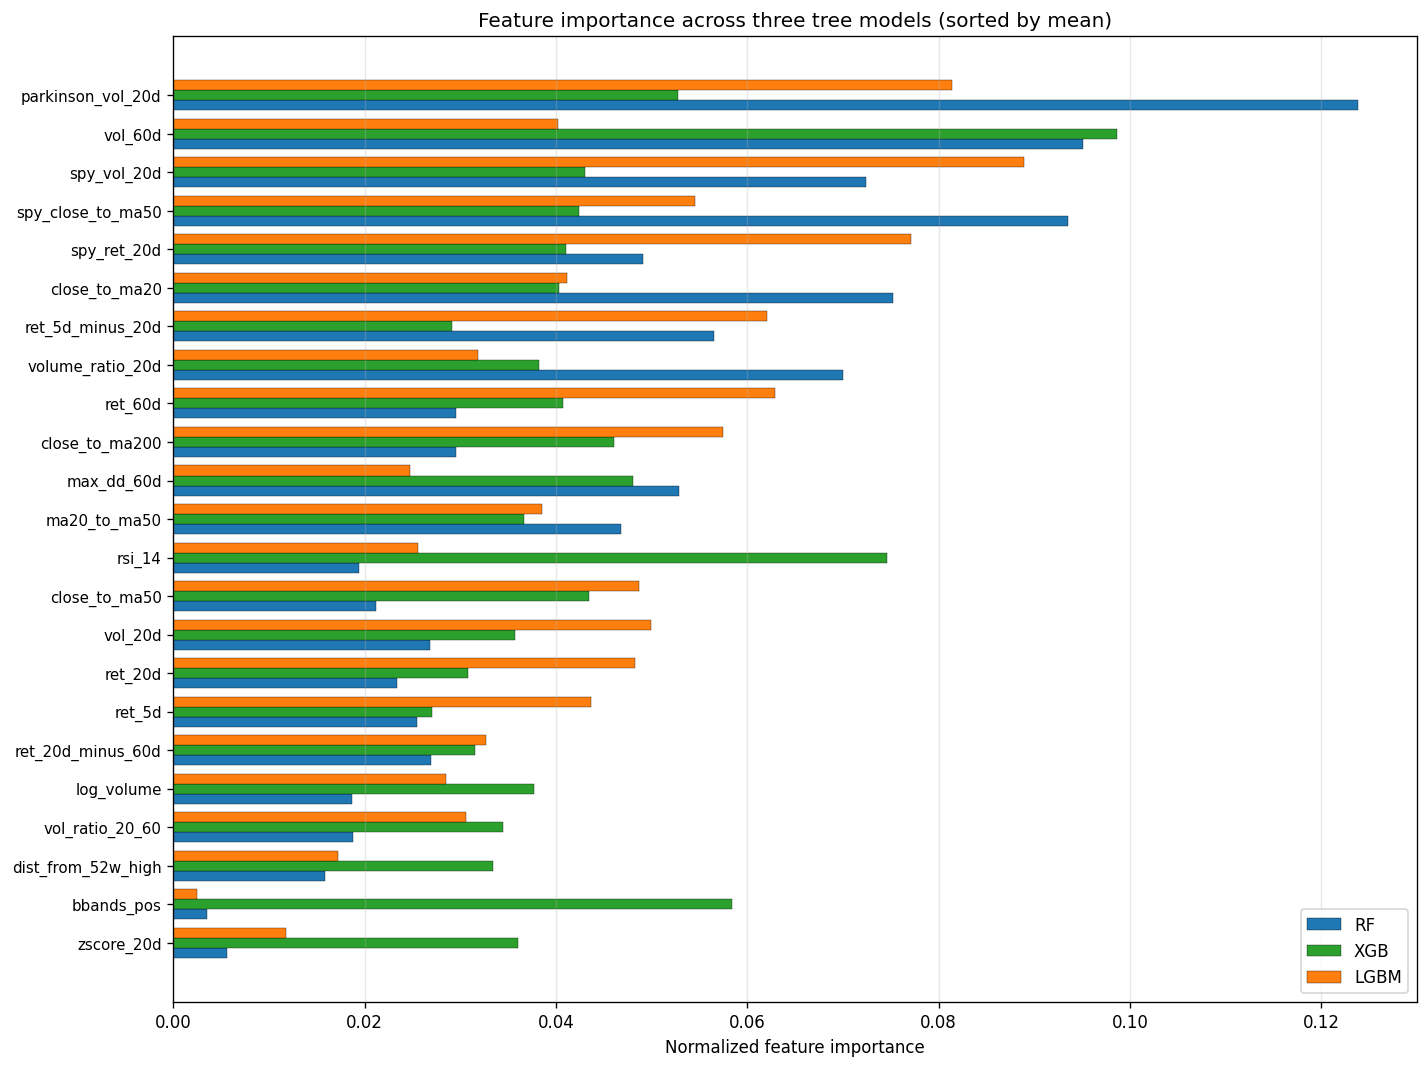

In [12]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES, name="xgb")
lgb_imp = pd.Series(
    lgbm.feature_importances_ / max(lgbm.feature_importances_.sum(), 1),
    index=ALL_FEATURES,
    name="lgbm",
)
rf_imp = pd.Series(rf.feature_importances_, index=ALL_FEATURES, name="rf")
combined = pd.concat([rf_imp, xgb_imp, lgb_imp], axis=1)
combined["mean"] = combined[["rf", "xgb", "lgbm"]].mean(axis=1)
combined = combined.sort_values("mean")

fig, ax = plt.subplots(figsize=(12, 9))
x = np.arange(len(combined))
w = 0.26
ax.barh(
    x - w,
    combined["rf"],
    w,
    label="RF",
    color="tab:blue",
    edgecolor="black",
    linewidth=0.2,
)
ax.barh(
    x,
    combined["xgb"],
    w,
    label="XGB",
    color="tab:green",
    edgecolor="black",
    linewidth=0.2,
)
ax.barh(
    x + w,
    combined["lgbm"],
    w,
    label="LGBM",
    color="tab:orange",
    edgecolor="black",
    linewidth=0.2,
)
ax.set_yticks(x)
ax.set_yticklabels(combined.index, fontsize=9)
ax.set_xlabel("Normalized feature importance")
ax.set_title("Feature importance across three tree models (sorted by mean)")
ax.grid(alpha=0.3, axis="x")
ax.legend()
fig.tight_layout()
fig.savefig(
    OUT_DIR / "feature_importance_cross_model.png", dpi=120, bbox_inches="tight"
)
plt.show()
plt.close(fig)